# PROJET PREDICTIF WALMART
## Objectifs

- EDA 

- ML regression linear BASELINE

- ML regression linear avec L1 et L2

- Benchmarck avec un autre modèle

In [68]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


# EDA

In [30]:
dataset = pd.read_csv('data/Walmart_Store_sales.csv')
print(dataset.head())
print(dataset.info())
dataset.describe(include='all').T

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0    6.0  18-02-2011    1572117.54           NaN        59.61       3.045   
1   13.0  25-03-2011    1807545.43           0.0        42.38       3.435   
2   17.0  27-07-2012           NaN           0.0          NaN         NaN   
3   11.0         NaN    1244390.03           0.0        84.57         NaN   
4    6.0  28-05-2010    1644470.66           0.0        78.89       2.759   

          CPI  Unemployment  
0  214.777523         6.858  
1  128.616064         7.470  
2  130.719581         5.936  
3  214.556497         7.346  
4  212.412888         7.092  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    flo

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Store,150.0,NaN,NaN,NaN,9.866667,6.231191,1.0,4.0,9.0,15.75,20.0
Date,132,85,19-10-2012,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekly_Sales,136.0,NaN,NaN,NaN,1249535.827941,647463.042349,268929.03,605075.7175,1261423.865,1806386.2,2771397.17
Holiday_Flag,138.0,NaN,NaN,NaN,0.07971,0.271831,0.0,0.0,0.0,0.0,1.0
Temperature,132.0,NaN,NaN,NaN,61.398106,18.378901,18.79,45.5875,62.985,76.345,91.65
Fuel_Price,136.0,NaN,NaN,NaN,3.320853,0.478149,2.514,2.85225,3.451,3.70625,4.193
CPI,138.0,NaN,NaN,NaN,179.898509,40.274956,126.111903,131.970831,197.908893,214.934616,226.968844
Unemployment,135.0,NaN,NaN,NaN,7.59843,1.577173,5.143,6.5975,7.47,8.15,14.313


In [31]:
#Drop Lines:
#target values missing
print('\nDropping target value missing rows...')
dataset.dropna(subset=['Weekly_Sales'], inplace=True)
print('...Done')

# Date: fill with forward fill (next known date)
print('\nFillin date with next known date...')
dataset['Date'] = dataset['Date'].ffill()
print('...Done')

# All other columns: fill with median (robust to outliers)
print('\nFillin others columns with median...')
cols_to_fill = ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in cols_to_fill:
    dataset[col] = dataset[col].fillna(dataset[col].median())
print('...Done')

# Store: should never be null but just in case
print('\nFillin date with next known date...')
dataset['Store'] = dataset['Store'].fillna(dataset['Store'].mode()[0])
print('...Done')

#Drop lines containing invalid values or outliers
print('\nDropping row with outliers in Temperature, Fuel_Price, CPI, Unemployment :')
for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    col_mean = dataset[col].mean()
    col_std = dataset[col].std()
    mask = (dataset[col] >= (col_mean - 3 * col_std)) &  (dataset[col]  <= (col_mean + 3 * col_std))
    dataset = dataset.loc[mask, :]
print('\nDone')

print('\nTransform Date column into usable feature...')
dataset['Date'] = pd.to_datetime(dataset['Date'], dayfirst=True, errors='coerce')
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['Day'] = dataset['Date'].dt.day
dataset['Week_Number'] = pd.to_datetime(dataset['Date']).dt.isocalendar().week.astype(int)
#dataset['Weekday'] = dataset['Date'].dt.day_name() -> not interesting because always a Friday (weekly report)
print('...Done')


print("\nBasics statistics: ")
display(dataset.describe(include='all').T)

print("\nPercentage of missing values: ")
print(dataset.isna().sum()/dataset.shape[0]*100)


Dropping target value missing rows...
...Done

Fillin date with next known date...
...Done

Fillin others columns with median...
...Done

Fillin date with next known date...
...Done

Dropping row with outliers in Temperature, Fuel_Price, CPI, Unemployment :

Done

Transform Date column into usable feature...
...Done

Basics statistics: 


,count,mean,min,25%,50%,75%,max,std
Store,131.0,9.938931,1.0,4.0,9.0,16.0,20.0,6.228663
Date,131,2011-04-27 14:39:23.358778624,2010-02-05 00:00:00,2010-07-30 00:00:00,2011-04-15 00:00:00,2012-01-09 12:00:00,2012-10-19 00:00:00,NaN
Weekly_Sales,131.0,1257990.439313,268929.03,584243.89,1366395.96,1809575.82,2771397.17,657746.320847
Holiday_Flag,131.0,0.061069,0.0,0.0,0.0,0.0,1.0,0.240376
Temperature,131.0,60.602977,18.79,47.085,62.25,75.045,91.65,17.453432
Fuel_Price,131.0,3.316473,2.514,2.8515,3.451,3.683,4.17,0.454986
CPI,131.0,181.581719,126.111903,133.361048,196.919506,214.781675,226.968844,38.290248
Unemployment,131.0,7.407718,5.143,6.833,7.477,8.059,9.524,0.939371
Year,131.0,2010.832061,2010.0,2010.0,2011.0,2012.0,2012.0,0.82418
Month,131.0,6.374046,1.0,4.0,6.0,9.0,12.0,3.242354



Percentage of missing values: 
Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
Year            0.0
Month           0.0
Day             0.0
Week_Number     0.0
dtype: float64


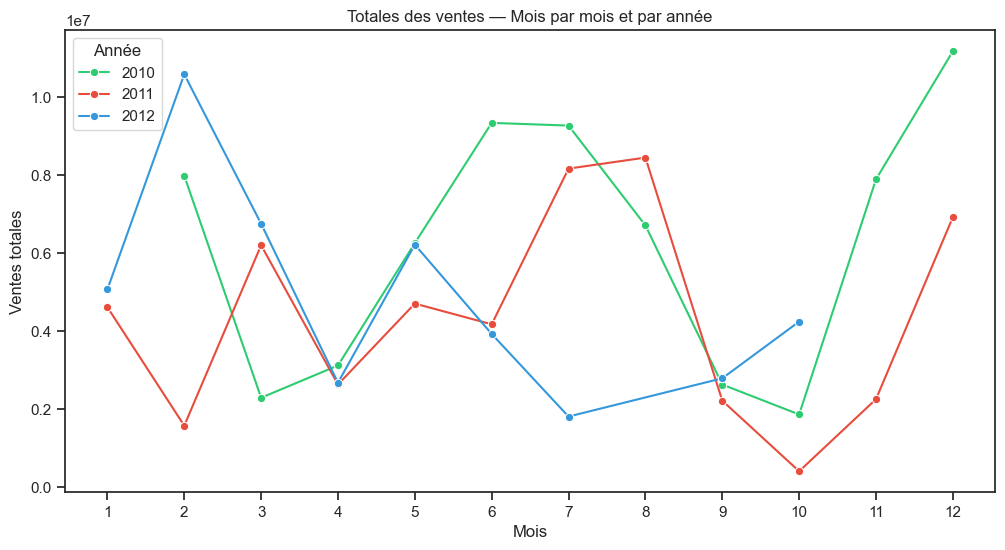

In [32]:
#Total sales per monthe and year
sales_month_year = dataset.groupby(["Year", "Month"], as_index=False)["Weekly_Sales"].sum()

#Graph of total sales per month and year
palette = ["#2ecc71", "#e74c3c", "#3498db"]  # one color per year

plt.figure(figsize=(12,6))
sns.lineplot(x="Month", y="Weekly_Sales", hue="Year", data=sales_month_year, marker="o", palette=palette)
plt.title("Totales des ventes — Mois par mois et par année")
plt.xlabel("Mois")
plt.ylabel("Ventes totales")
plt.xticks(range(1,13))

# Fix year labels to show as integers (no decimal)
legend = plt.legend(title="Année")
for text in legend.get_texts():
    text.set_text(str(int(float(text.get_text()))))

plt.show()

/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_22849/2509330811.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




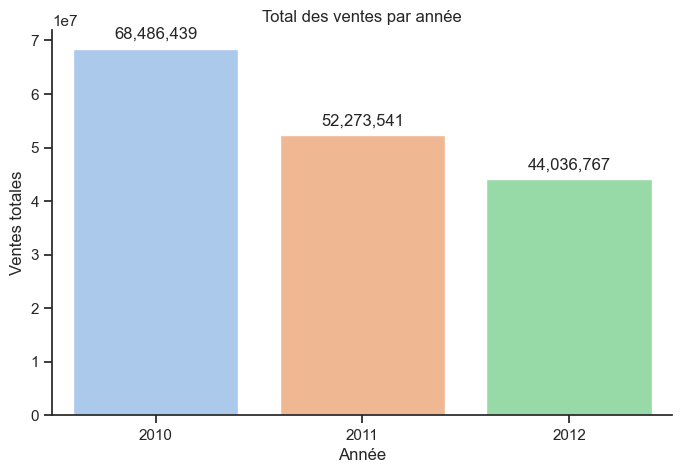

In [33]:
# Total sales per year
sales_year = dataset.groupby("Year", as_index=False)["Weekly_Sales"].sum()

# Graph
plt.figure(figsize=(8,5))
ax = sns.barplot(x="Year", y="Weekly_Sales", data=sales_year, palette="pastel")
plt.title("Total des ventes par année")
plt.ylabel("Ventes totales")
plt.xlabel("Année")

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=5)
    
# Remove top and left borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

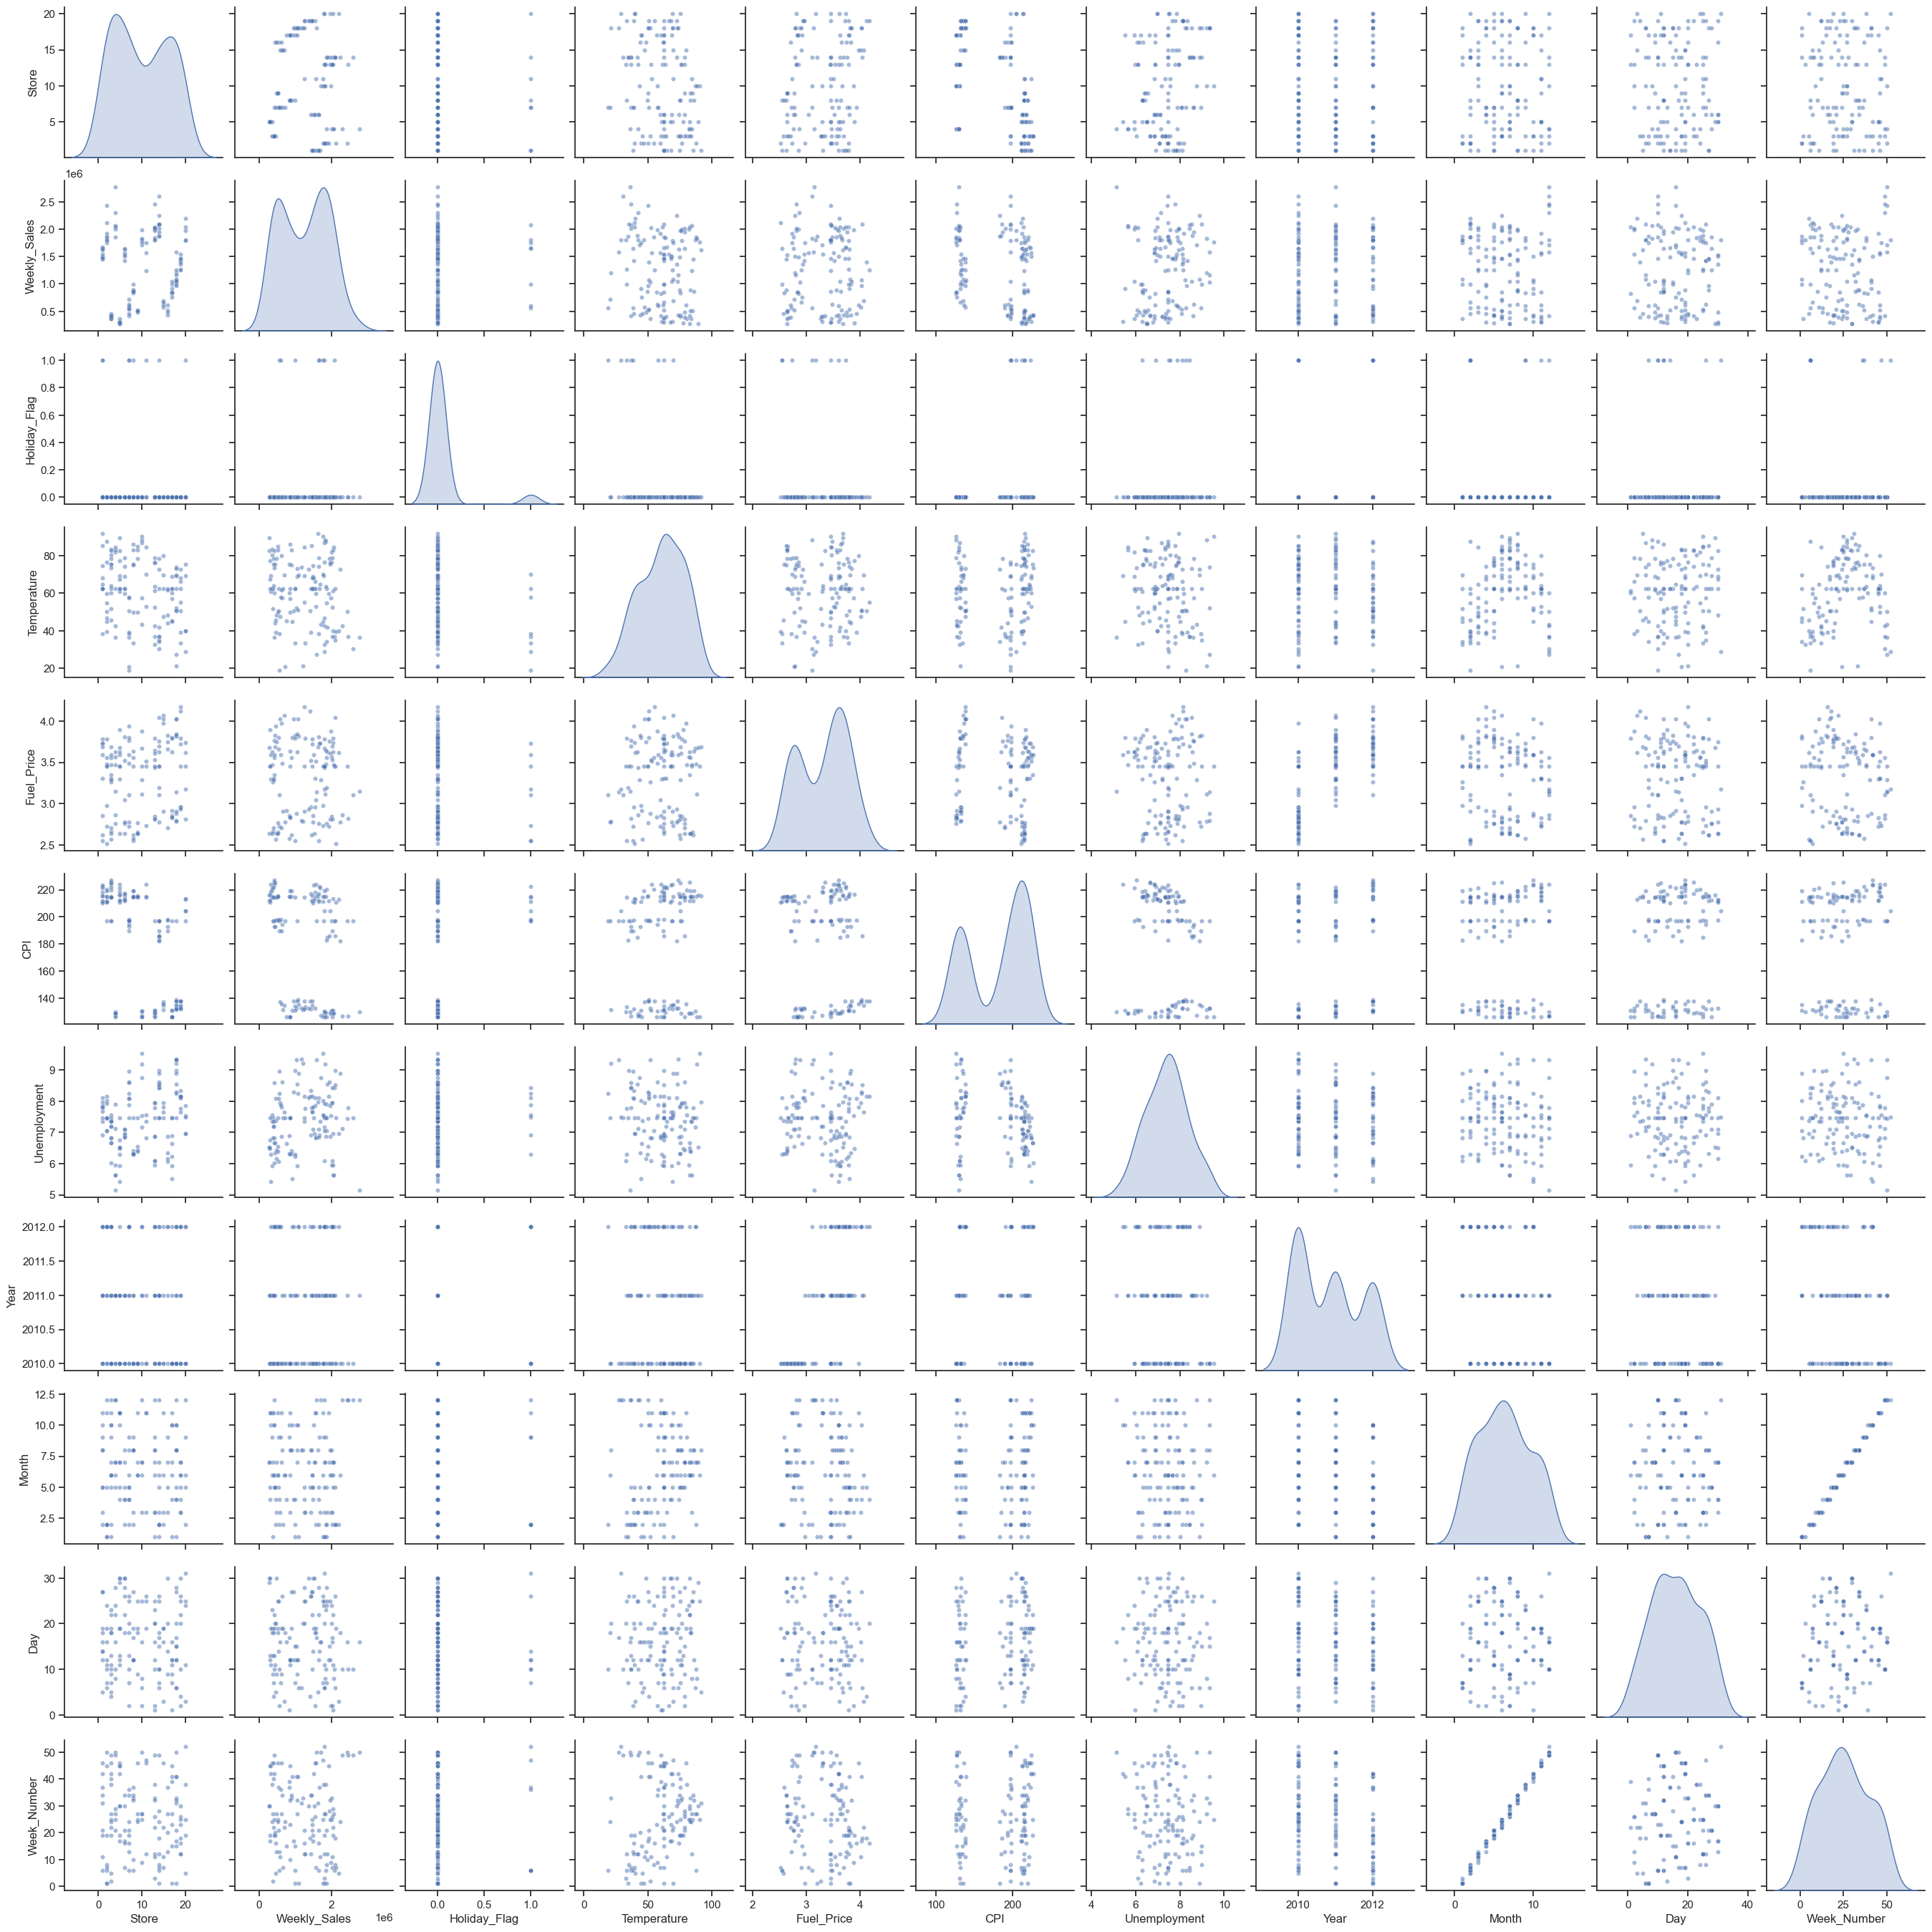

In [34]:
#Visualization relationship between numeric features
sns.set_theme(style="ticks")

sns.pairplot(dataset, diag_kind="kde", plot_kws={"alpha": 0.5, "s": 20})
plt.show()

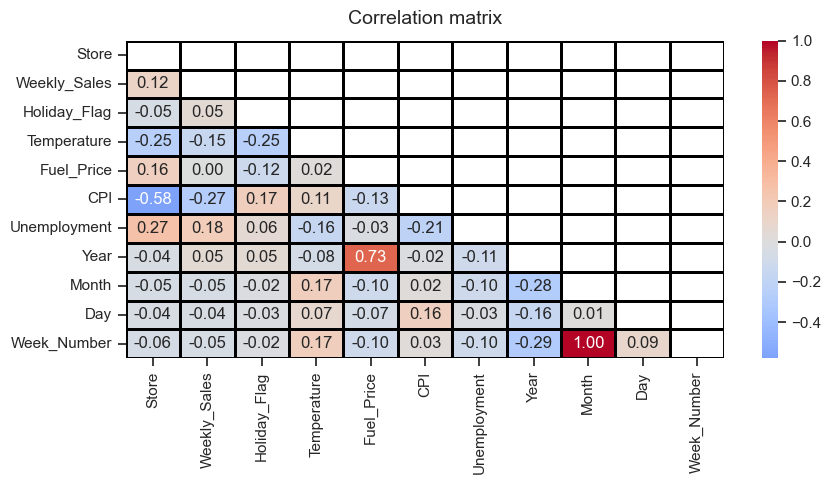

In [35]:
# Correlation matrix
corr_matrix = dataset.corr(numeric_only=True).round(2)
f, ax = plt.subplots(figsize=(9, 5))
mask_sns = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax, mask=mask_sns, annot=True, center=0,
            cmap="coolwarm", linewidths=1, fmt=".2f",
            linecolor="black", cbar_kws={"shrink": 1, "orientation": "vertical"})
ax.set_title("Correlation matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

-> corrélation forte entre year and Fuel price -> enlever 'year' comme feature

-> corrélation très forte entre week_number et month -> supprimer week_number ici

### Features selection

Ni le mois ni week_number n'ont de relation véritablement linéaire avec les ventes : le mois 12 n'est pas « 12 fois » le mois 1, et il n'existe aucun ordre inhérent qu'une représentation numérique permettrait de saisir correctement. -> variables catégorielles

In [50]:
# Separate target variable Y from features X
print("Separating labels from features...")
target_variable = "Weekly_Sales"

X = dataset.drop(target_variable, axis=1)
Y = dataset.loc[:, target_variable]

X = X.drop(['Year', 'Day', 'Date', 'Week_Number'], axis=1)  #-> not using a time series model, so date can't be used as a feature

print("...Done.")

# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = ['Store', 'Holiday_Flag', 'Month']
for col in X.columns:
    if col not in categorical_features:
        numeric_features.append(col)

print("Numeric features ", numeric_features)
print("Categorical features ", categorical_features)

Separating labels from features...
...Done.
Numeric features  ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
Categorical features  ['Store', 'Holiday_Flag', 'Month']


### Preprocessing

In [51]:

# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
# No need of stratify=Y. Here not a classification problems
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("...Done.")

#For Numeric features: normalization
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#For Categorical features: missing + normalization
categorical_transformer = Pipeline(
    steps = [('imputer', SimpleImputer(strategy='most_frequent')),
     ('encoder',OneHotEncoder(handle_unknown="ignore", drop="first"))
     ])
preprocessor = ColumnTransformer(
    transformers = [
         ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

# Preprocessing on train set
print("Performing preprocessings on train set...")
X_train = preprocessor.fit_transform(X_train)
print("...Done.")

# Preprocessing on test set
print("Performing preprocessings on test set...")
X_test = preprocessor.transform(X_test)
print("...Done.")

Dividing into train and test sets...
...Done.
Performing preprocessings on train set...
...Done.
Performing preprocessings on test set...
...Done.


# Baseline model: linear regression

In [52]:
# Train linear model
print("Train Linear model...")
regressor_base_line = LinearRegression()
regressor_base_line.fit(X_train, Y_train)
print("...Done")

Y_pred_train = regressor_base_line.predict(X_train)
Y_pred_test  = regressor_base_line.predict(X_test)

print("R2  — train :", round(regressor_base_line.score(X_train, Y_train), 4))
print("R2  — test  :", round(regressor_base_line.score(X_test,  Y_test),  4))
print("MAE — test  :", round(mean_absolute_error(Y_test, Y_pred_test), 2))
print("RMSE— test  :", round(root_mean_squared_error(Y_test, Y_pred_test), 2))

Train Linear model...
...Done
R2  — train : 0.9824
R2  — test  : 0.895
MAE — test  : 129678.25
RMSE— test  : 191006.67


R2 -> part de la variance expliquée par le modèle
MAE (Mean average error) -> erreur moyenne absolue, même unité que weekly sales 
RMSE -> pénalise plus les erreurs importantes que la MAE -> utile pour détecter modèle à des difficultés lors de certaines semaines

R2 -> important -> le modèle explique à 98% la variance des ventes hebdomadaires
R2 train > R2 test -> overfitting 

-> petit dataset (131 après cleanup) -> utiliser cross-validation

MAE de 130k$ -> le modèle se trompe de 130k$ par semaine et par magasin. Moyennes des ventes =1,23million par semaine -> MAE se trompe de 9%

RMSE > MAE (191k$ contre 130k$) signifie qu’il y a certaines semaines où le modèle commet des erreurs nettement plus importantes —> probablement autour des jours fériés ou des périodes promotionnelles

# Ridge regularization

Ridge Grid search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
...Done.
Ridge Best hyperparameters : {'alpha': np.int64(0)}
Ridge Best R2 score : 0.9337
Ridge R2 score on training set : 0.9824
Ridge R2 score on test set     : 0.8949
Ridge Cross-validated R2 (mean): 0.9379
Ridge Standard deviation       : 0.0389


/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_22849/545195500.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




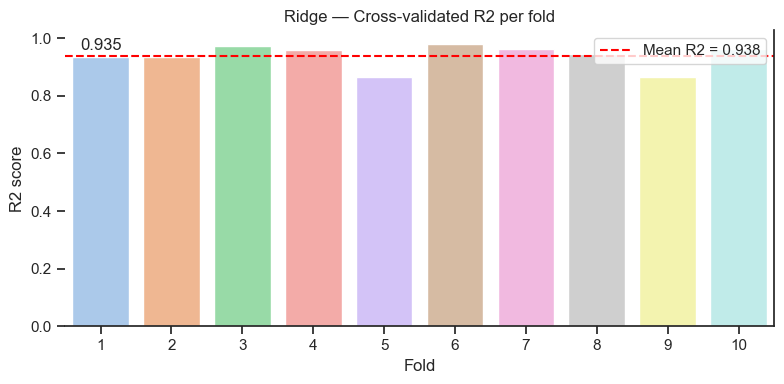

In [56]:
# Perform grid search
print("Ridge Grid search...")
regressor_ridge = Ridge()
params = {
    'alpha': np.arange(0, 1000, 10)
}
gridsearch_ridge = GridSearchCV(
    regressor_ridge,
    param_grid=params,
    cv=5,
    verbose=1,
    scoring='r2'
)
gridsearch_ridge.fit(X_train, Y_train)
print("...Done.")
print("Ridge Best hyperparameters :", gridsearch_ridge.best_params_)
print("Ridge Best R2 score :", round(gridsearch_ridge.best_score_, 4))

# Print R2 scores
print("Ridge R2 score on training set :", round(gridsearch_ridge.score(X_train, Y_train), 4))
print("Ridge R2 score on test set     :", round(gridsearch_ridge.score(X_test,  Y_test),  4))

# Cross-validated score on best estimator — more reliable than single test split on small dataset
scores_ridge = cross_val_score(gridsearch_ridge.best_estimator_, X_train, Y_train, cv=10)
print("Ridge Cross-validated R2 (mean):", round(scores_ridge.mean(), 4))
print("Ridge Standard deviation       :", round(scores_ridge.std(),  4))

# Plot CV scores across folds
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=list(range(1, 11)), y=scores_ridge, palette="pastel")
ax.bar_label(ax.containers[0], fmt="{:.3f}", padding=3)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.axhline(scores_ridge.mean(), color="red", linestyle="--", label=f"Mean R2 = {scores_ridge.mean():.3f}")
plt.title("Ridge — Cross-validated R2 per fold")
plt.xlabel("Fold")
plt.ylabel("R2 score")
plt.legend()
plt.tight_layout()
plt.show()

# Lasso regularization

Lasso Grid search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
...Done.
Lasso Best hyperparameters : {'alpha': np.float64(780.1)}
Lasso Best R2 score : 0.9505
Lasso R2 score on training set : 0.9809
Lasso R2 score on test set     : 0.9035
Lasso Cross-validated R2 (mean): 0.946
Lasso Standard deviation       : 0.0403


/var/folders/d2/j007c_wj355g0r_h_j5t1vrc0000gn/T/ipykernel_22849/708523303.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




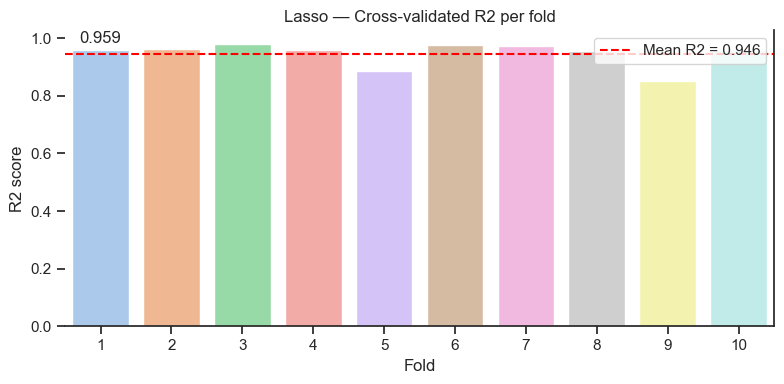

In [57]:
# Perform grid search
print("Lasso Grid search...")
regressor_lasso = Lasso(max_iter=10000)
params = {
    'alpha': np.arange(0.1, 1000, 10)
}
gridsearch_lasso = GridSearchCV(
    regressor_lasso,
    param_grid=params,
    cv=5,
    verbose=1,
    scoring='r2'
)
gridsearch_lasso.fit(X_train, Y_train)
print("...Done.")
print("Lasso Best hyperparameters :", gridsearch_lasso.best_params_)
print("Lasso Best R2 score :", round(gridsearch_lasso.best_score_, 4))

# Print R2 scores
print("Lasso R2 score on training set :", round(gridsearch_lasso.score(X_train, Y_train), 4))
print("Lasso R2 score on test set     :", round(gridsearch_lasso.score(X_test,  Y_test),  4))

# Cross-validated score on best estimator
scores_lasso = cross_val_score(gridsearch_lasso.best_estimator_, X_train, Y_train, cv=10)
print("Lasso Cross-validated R2 (mean):", round(scores_lasso.mean(), 4))
print("Lasso Standard deviation       :", round(scores_lasso.std(),  4))

# Plot CV scores across folds
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=list(range(1, 11)), y=scores_lasso, palette="pastel")
ax.bar_label(ax.containers[0], fmt="{:.3f}", padding=3)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.axhline(scores_lasso.mean(), color="red", linestyle="--", label=f"Mean R2 = {scores_lasso.mean():.3f}")
plt.title("Lasso — Cross-validated R2 per fold")
plt.xlabel("Fold")
plt.ylabel("R2 score")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Summary table (with best hyperparameters and CV scores)
print("Summary table (with best hyperparameters and CV scores)")
print(f"\n{'Model':<25} {'R2 Train':>8} {'R2 Test':>8} {'CV R2':>8} {'CV Std':>8}")
print("=" * 65)
print(f"{'Linear Regression':<25} {regressor_base_line.score(X_train, Y_train):>8.4f} {regressor_base_line.score(X_test, Y_test):>8.4f} {'—':>8} {'—':>8}")
print(f"{'Ridge (α=' + str(gridsearch_ridge.best_params_['alpha']) + ')':<25} {gridsearch_ridge.score(X_train, Y_train):>8.4f} {gridsearch_ridge.score(X_test, Y_test):>8.4f} {scores_ridge.mean():>8.4f} {scores_ridge.std():>8.4f}")
print(f"{'Lasso (α=' + str(gridsearch_lasso.best_params_['alpha']) + ')':<25} {gridsearch_lasso.score(X_train, Y_train):>8.4f} {gridsearch_lasso.score(X_test, Y_test):>8.4f} {scores_lasso.mean():>8.4f} {scores_lasso.std():>8.4f}")
print("=" * 65)

Summary table (with best hyperparameters and CV scores)

Model                     R2 Train  R2 Test    CV R2   CV Std
Linear Regression           0.9824   0.8950        —        —
Ridge (α=0)                 0.9824   0.8949   0.9379   0.0389
Lasso (α=780.1)             0.9809   0.9035   0.9460   0.0403


Ridge α=0 —> ce qui confirme que la régularisation n'apporte rien à Ridge

Lasso gagne avec un CV supérieur (faible marge). α=780.1 -> fortre régularisation, les coeff sont réduits de manière agréssive. -> pb avec faible taille échantillon

### Benchmarck autres modèles

In [ ]:
# Models
models = [
    ("RandomForest", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,        # avec 4 -> underfit, 14 -> overfit. 8 au milieu
        min_samples_leaf=3, # 5 — moins contraingnant
        max_features=0.7,  
        random_state=42,
        n_jobs=-1
    )),
    ("ExtraTrees", ExtraTreesRegressor(
        n_estimators=200,
        max_depth=8,        # same reasoning
        min_samples_leaf=3,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )),
    ("XGBoost", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,         # avec 3 -> underfit, 6 -> overfit. 4 au milieu
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5, 
        reg_lambda=2.0, 
        min_child_weight=3,
        random_state=42,
        n_jobs=-1
    )),
]

def score(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

# Train + score all models
results = []
for name, model in models:
    model.fit(X_train, Y_train)
    pred = model.predict(X_test)
    rmse, mae, r2 = score(Y_test, pred)

    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')

    results.append({
        "model":    name,
        "r2_train": round(r2_score(Y_train, model.predict(X_train)), 4),
        "r2_test":  round(r2, 4),
        "cv_r2":    round(cv_scores.mean(), 4),
        "cv_std":   round(cv_scores.std(), 4),
        "mae":      round(mae, 2),
        "rmse":     round(rmse, 2),
    })

res = pd.DataFrame(results).sort_values("rmse")

print("=== Benchmark on TEST (lower RMSE is better) ===")
print(res.to_string(index=False))

# Full comparison including linear models
print("\n=== Full model comparison ===")
print("=" * 75)
print(f"{'Model':<30} {'R2 Train':>8} {'R2 Test':>8} {'CV R2':>8} {'CV Std':>8}")
print("=" * 75)
print(f"{'Linear Regression':<30} {regressor_base_line.score(X_train, Y_train):>8.4f} {regressor_base_line.score(X_test, Y_test):>8.4f} {'—':>8} {'—':>8}")
print(f"{'Ridge (α=' + str(gridsearch_ridge.best_params_['alpha']) + ')':<30} {gridsearch_ridge.score(X_train, Y_train):>8.4f} {gridsearch_ridge.score(X_test, Y_test):>8.4f} {scores_ridge.mean():>8.4f} {scores_ridge.std():>8.4f}")
print(f"{'Lasso (α=' + str(gridsearch_lasso.best_params_['alpha']) + ')':<30} {gridsearch_lasso.score(X_train, Y_train):>8.4f} {gridsearch_lasso.score(X_test, Y_test):>8.4f} {scores_lasso.mean():>8.4f} {scores_lasso.std():>8.4f}")
for row in results:
    print(f"{row['model']:<30} {row['r2_train']:>8.4f} {row['r2_test']:>8.4f} {row['cv_r2']:>8.4f} {row['cv_std']:>8.4f}")
print("=" * 75)

=== Benchmark on TEST (lower RMSE is better) ===
       model  r2_train  r2_test  cv_r2  cv_std       mae      rmse
  ExtraTrees    0.8661   0.7886 0.6367  0.0544 215539.93 270982.47
     XGBoost    0.9800   0.7519 0.7030  0.0980 249869.85 293570.68
RandomForest    0.8664   0.5200 0.4454  0.1066 335075.95 408312.81

=== Full model comparison ===
Model                          R2 Train  R2 Test    CV R2   CV Std
Linear Regression                0.9824   0.8950        —        —
Ridge (α=0)                      0.9824   0.8949   0.9379   0.0389
Lasso (α=780.1)                  0.9809   0.9035   0.9460   0.0403
RandomForest                     0.8664   0.5200   0.4454   0.1066
ExtraTrees                       0.8661   0.7886   0.6367   0.0544
XGBoost                          0.9800   0.7519   0.7030   0.0980


### Conclusion

Les méthodes d'ensemble (RandomForest, ExtraTrees, XGBoost) affichent des performances nettement inférieures à celles des modèles linéaires régularisés sur cet ensemble de données. 

131 échantillons, ces modèles complexes ne peuvent pas généraliser -> soit surapprentissage, soit de sous-apprentissage. 

La régression Lasso avec α = 780,1 offre le meilleur équilibre : R² test = 0,903, R² CV = 0,946.

Un ensemble de données plus volumineux serait nécessaire pour exploiter pleinement le potentiel des méthodes d'ensemble.